In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares, root
import warnings
warnings.filterwarnings("ignore", category = RuntimeWarning)

In [2]:
## Disk parameters
alpha = 1e-3
M_disk = 0.1 # M_sun
T_0 = 18.9737 # K
a_c = 50 # AU
a_min = 0.1 # AU
a_max = 1000 # AU
d2g = 0.01
D = 0.2
b_tilde = 10
mu = 2.33
v_frag = 100 # cm/s
epsilon_g = 0.5

## Star parameters
M_star = 1.0 # M_sun
R_star = 2.5 # R_sun
T_eff = 4000 # K

## Planetesimal parameters
rho_pltsml = 2.0 # g/cm^3
R_pltsml = 100 # km

## Embryo core parameters
rho_core = 2.0 # g/cm^3

## Constants
G = 6.67e-8 # cm^3/g/s^2
k_B = 1.38e-16 # erg/K
sigma_B = 5.67e-5 # erg/cm^2/s/K^4
m_H = 1.67e-24 # g
M_earth = 5.97e27 # g
M_sun = 1.99e33 # g
R_sun = 6.96e10 # cm
L_sun = 3.839e33 # erg/s
AU = 1.496e13 # cm
year = 3.156e7 # s
sigma_H2 = 2.61e-15 # cm^2

In [3]:
## Disk structure helper functions

def Sigma_0(M_disk, a_c):
    """Calculates the normalization constant for the surface density profile."""
    return M_disk * M_sun / (2 * np.pi * (a_c * AU) ** 2)

def Sigma_g(a):
    """Calculates the gas surface density of the disk in g/cm^2."""
    return Sigma_0(M_disk, a_c) * (a / a_c) ** (-1) * np.exp(-a / a_c)

def Sigma_s(a):
    """Calculates the solid surface density of the disk in g/cm^2."""
    return d2g * Sigma_g(a)

def T(a):
    """Calculates the temperature of the disk in K."""
    return T_0 * (a / a_c) ** (-0.5)

def Reynolds(e2, i2, a):
    """Calculates the Reynolds number."""
    nu_mol = mfp_H2(a) * c_s(a) / 3
    return v_rel(e2, i2, a) * (R_pltsml * 1e5) / nu_mol

def c_s(a):
    """Calculates the sound speed of the disk in cm/s."""
    return np.sqrt(k_B * T(a) / (mu * m_H))

def H(a):
    """Calculates the scale height of the disk in AU."""
    return c_s(a) / Omega_K(a) / AU

def mfp_H2(a):
    """Calculates the mean free path of H2 in cm."""
    n_H2 = rho_mid(a) / (mu * m_H)
    return (n_H2 * sigma_H2) ** (-1)

def rho_mid(a):
    """Calculates the midplane gas density of the disk in g/cm^3."""
    return Sigma_g(a) / (np.sqrt(2 * np.pi) * H(a) * AU)

## Embryo and planetesimal helper functions

def v_rel(e2, i2, a):
    """Calculates the relative velocity between planetesimals and the embryo in cm/s (Fortier et al. 2012)."""
    return Omega_K(a) * a * AU * np.sqrt(5/8 * e2 + 1/2 * i2)

def M_pltsml(R_pltsml):
    """Calculates the mass of a planetesimal assuming constant density in Earth masses."""
    return (4/3) * np.pi * (R_pltsml * 1e5) ** 3 * rho_pltsml / M_earth

def Omega_K(a):
    """Calculates the Keplerian angular velocity in rad/s."""
    return np.sqrt(G * M_star * M_sun / (a * AU) ** 3)

def R_core(M_core):
    """Calculates the core radius assuming a constant density in km."""
    return (3 * M_core * M_earth / (4 * np.pi * rho_core)) ** (1/3) / 1e5

def R_H(M_core, a_core):
    """Calculates the Hill radius in AU."""
    return a_core * (M_core * M_earth / (3 * M_star * M_sun)) ** (1/3)

## Eccentricity and inclination helper functions

def f_j(a_0, a_j, M_j):
    """Distance modulation function for embryo j (Kaufmann & Alibert 2023)."""
    return 1 / (1 + abs(a_0 - a_j) / (5 * R_H(M_j, a_j)))

def P_VS(e_tilde, i_tilde):
    """Stirring function for eccentricity (Kaufmann & Alibert 2023)."""
    Lambda = 1/12 * (e_tilde ** 2 + i_tilde ** 2) * i_tilde
    beta = i_tilde / e_tilde
    return (73 * e_tilde ** 2) / (10 * Lambda ** 2) * np.log(1 + 10 * Lambda ** 2 / (e_tilde ** 2)) + (72 * I_PVS(beta)) / (np.pi * e_tilde * i_tilde) * np.log(1 + Lambda ** 2)

def Q_VS(e_tilde, i_tilde):
    """Stirring function for inclination (Kaufmann & Alibert 2023)."""
    Lambda = 1/12 * (e_tilde ** 2 + i_tilde ** 2) * i_tilde
    beta = i_tilde / e_tilde
    return (4 * i_tilde ** 2 + 0.2 * i_tilde * e_tilde ** 3) / (10 * Lambda ** 2 * e_tilde) * np.log(1 + 10 * Lambda ** 2 * e_tilde) + (72 * I_QVS(beta)) / (np.pi * e_tilde * i_tilde) * np.log(1 + Lambda ** 2)

def I_PVS(beta):
    """Numerical elliptic integral approximation (Kaufmann & Alibert 2023)."""
    return (beta - 0.36251) / (0.061547 + 0.16112 * beta + 0.054473 * beta ** 2)

def I_QVS(beta):
    """Numerical elliptic integral approximation (Kaufmann & Alibert 2023)."""
    return (0.71946 - beta) / (0.21239 + 0.49764 * beta + 0.14369 * beta ** 2)

def t_stop(e2, i2, a_0):
    """Planetesimal gas drag stopping time in s (Kaufmann & Alibert 2023)."""

    if R_pltsml * 1e5 < 1.5 * mfp_H2(a_0):
        return rho_pltsml * (R_pltsml * 1e5) / (rho_mid(a_0) * c_s(a_0))
    
    else:
        if Reynolds(e2, i2, a_0) < 27:
            return 2 * rho_pltsml * (R_pltsml * 1e5) ** 2 / (3 * rho_mid(a_0) * mfp_H2(a_0) * c_s(a_0))
        
        else:
            return 6 * rho_pltsml * (R_pltsml * 1e5) / (rho_mid(a_0) * v_rel(e2, i2, a_0))

def e_tilde_embryo(e2, M_core):
    """Calculates the embryo reduced eccentricity."""
    return np.sqrt(np.maximum(e2, 0)) / (M_core * M_earth / (3 * M_star * M_sun)) ** (1/3)

def i_tilde_embryo(i2, M_core):
    """Calculates the embryo reduced inclination."""
    return np.sqrt(np.maximum(i2, 0)) / (M_core * M_earth / (3 * M_star * M_sun)) ** (1/3)

def e_tilde_pltsml(e2):
    """Calculates the planetesimal reduced eccentricity."""
    return 2 * np.sqrt(np.maximum(e2, 0)) / (2 * M_pltsml(R_pltsml) * M_earth / (3 * M_star * M_sun)) ** (1/3)

def i_tilde_pltsml(i2):
    """Calculates the planetesimal reduced inclination."""
    return 2 * np.sqrt(np.maximum(i2, 0)) / (2 * M_pltsml(R_pltsml) * M_earth / (3 * M_star * M_sun)) ** (1/3)

## Rafikov planetesimal accretion helper functions

def v_esc(M_core):
    """Calculates the escape velocity from the core in cm/s."""
    return np.sqrt(2 * G * M_core * M_earth / (R_core(M_core) * 1e5))

def v_H(M_core, a_core):
    """Calculates the Hill velocity in cm/s."""
    return Omega_K(a_core) * R_H(M_core, a_core) * AU

def v_low(M_core, a_core):
    """Calculates the dynamically thin disk regime threshold in cm/s (Rafikov 2011)."""
    return Omega_K(a_core) * np.sqrt((R_H(M_core, a_core) * AU) * (R_core(M_core) * 1e5))

def p(M_core, a_core):
    """Calculates the ratio of the core radius to the Hill radius."""
    return (R_core(M_core) * 1e5) / (R_H(M_core, a_core) * AU)

def s(M_core, sigma, a_core):
    """Calculates the ratio of the velocity dispersion of the planetesimals to the Hill velocity."""
    return sigma / v_H(M_core, a_core)

## Fortier planetesimal accretion helper functions

def I_F(beta):
    """Numerical elliptic integral approximation (Fortier et al 2012)."""
    return (1 + 0.95925 * beta + 0.77251 * beta ** 2) / (beta * (0.13142 + 0.12295 * beta))

def I_G(beta):
    """Numerical elliptic integral approximation (Fortier et al 2012)."""
    return (1 + 0.3996 * beta) / (beta * (0.0369 + 0.048333 * beta + 0.006874 * beta ** 2))

def P_high(e2, i2, a_core, M_core):
    """Calculates the high collisional rate (Fortier et al 2012)."""
    e_tilde = e_tilde_embryo(e2, M_core)
    i_tilde = i_tilde_embryo(i2, M_core)
    beta = i_tilde / e_tilde
    return ((R_core(M_core) * 1e5 + R_pltsml * 1e5) ** 2 / (2 * np.pi * (R_H(M_core, a_core) * AU) ** 2)) * (I_F(beta) + 6 * R_H(M_core, a_core) * AU * I_G(beta) / ((R_core(M_core) * 1e5 + R_pltsml * 1e5) * e_tilde ** 2))

def P_med(e2, i2, a_core, M_core):
    """Calculates the medium collisional rate (Fortier et al 2012)."""
    e_tilde = e_tilde_embryo(e2, M_core)
    i_tilde = i_tilde_embryo(i2, M_core)
    beta = i_tilde / e_tilde
    return ((R_core(M_core) * 1e5 + R_pltsml * 1e5) ** 2 / (4 * np.pi * (R_H(M_core, a_core) * AU) ** 2) * i_tilde) * (17.3 + 232 * R_H(M_core, a_core) * AU / (R_core(M_core) * 1e5 + R_pltsml * 1e5))

def P_low(e2, i2, a_core, M_core):
    """Calculates the low colisional rate (Fortier et al 2012)."""
    e_tilde = e_tilde_embryo(e2, M_core)
    i_tilde = i_tilde_embryo(i2, M_core)
    beta = i_tilde / e_tilde
    return 11.3 * ((R_core(M_core) * 1e5 + R_pltsml * 1e5) / (R_H(M_core, a_core) * AU)) ** (1/2)

def P_coll(e2, i2, a_core, M_core):
    """Calculates the probability that the planetesimal is accreted by the embryo (Fortier et al 2012)."""
    return np.min((P_med(e2, i2, a_core, M_core), (P_high(e2, i2, a_core, M_core) ** (-2) + P_low(e2, i2, a_core, M_core) ** (-2)) ** (-1/2)), axis = 0)

In [4]:
## Wrapper function for scipy.optimize.least_squares() or scipy.optimize.root()

def equilibrium(x, a_0, a_cores, M_cores, drag = True, VS_embryo = True, VS_pltsml = True, DF = True):
    """Returns [de2/dt, di2/dt] for a trial [e2, i2]."""
    e2, i2 = x

    return np.array([de2_dt(e2, i2, a_0, a_cores, M_cores, drag, VS_embryo, VS_pltsml, DF) * 1e6 * year, di2_dt(e2, i2, a_0, a_cores, M_cores, drag, VS_embryo, VS_pltsml, DF) * 1e6 * year])

## ODEs

def de2_dt(e2, i2, a_0, a_cores, M_cores, drag = True, VS_embryo = True, VS_pltsml = True, DF = True):
    """Evolution equation for local planetesimal eccentricity squared (Kaufmann & Alibert 2023)."""
    e2_dot = 0

    if drag:
        e2_dot += de2_dt_drag(e2, i2, a_0)

    if VS_embryo:
        e2_dot += de2_dt_VS_embryo(e2, i2, a_0, a_cores, M_cores)

    if VS_pltsml:
        e2_dot += de2_dt_VS_pltsml(e2, i2, a_0)

    if DF:
        e2_dot += de2_dt_DF(e2, i2, a_0)
    
    return e2_dot

def di2_dt(e2, i2, a_0, a_cores, M_cores, drag = True, VS_embryo = True, VS_pltsml = True, DF = True):
    """Evolution equation for local planetesimal inclination squared (Kaufmann & Alibert 2023)."""
    i2_dot = 0

    if drag:
        i2_dot += di2_dt_drag(e2, i2, a_0)

    if VS_embryo:
        i2_dot += di2_dt_VS_embryo(e2, i2, a_0, a_cores, M_cores)

    if VS_pltsml:
        i2_dot += di2_dt_VS_pltsml(e2, i2, a_0)

    if DF:
        i2_dot += di2_dt_DF(e2, i2, a_0)
    
    return i2_dot

## Gas drag terms

def de2_dt_drag(e2, i2, a_0):
    """Gas drag term in eccentricity evolution (Kaufmann & Alibert 2023)."""

    if R_pltsml * 1e5 < 1.5 * mfp_H2(a_0):
        return -1 * e2 * c_s(a_0) * rho_mid(a_0) / (rho_pltsml * R_pltsml * 1e5)
    
    else:
        if Reynolds(e2, i2, a_0) < 27:
            return -3/2 * e2 * mfp_H2(a_0) * c_s(a_0) * rho_mid(a_0) / (rho_pltsml * (R_pltsml * 1e5) ** 2)
        
        else:
            return -2 * e2 * v_rel(e2, i2, a_0) * rho_mid(a_0) / (6 * rho_pltsml * R_pltsml * 1e5)

def di2_dt_drag(e2, i2, a_0):
    """Gas drag term in inclination evolution (Kaufmann & Alibert 2023)."""

    if R_pltsml * 1e5 < 1.5 * mfp_H2(a_0):
        return -1/2 * i2 * c_s(a_0) * rho_mid(a_0) / (rho_pltsml * R_pltsml * 1e5)
    
    else:
        if Reynolds(e2, i2, a_0) < 27:
            return -3/4 * i2 * mfp_H2(a_0) * c_s(a_0) * rho_mid(a_0) / (rho_pltsml * (R_pltsml * 1e5) ** 2)
        
        else:
            return -1 * i2 * v_rel(e2, i2, a_0) * rho_mid(a_0) / (6 * rho_pltsml * R_pltsml * 1e5)
        
## Planetesimal viscous stirring terms

def de2_dt_VS_pltsml(e2, i2, a_0):
    """Viscous stirring due to planetesimal-planetesimal interactions (Fortier et al 2012)."""
    e_tilde = e_tilde_pltsml(e2)
    i_tilde = i_tilde_pltsml(i2)
    return 1/6 * np.sqrt(G * a_0 * AU / (M_star * M_sun)) * Sigma_s(a_0) * (2 * M_pltsml(R_pltsml) * M_earth / (3 * M_star * M_sun)) ** (1/3) * P_VS(e_tilde, i_tilde)

def di2_dt_VS_pltsml(e2, i2, a_0):
    """Viscous stirring due to planetesimal-planetesimal interactions (Fortier et al 2012)."""
    e_tilde = e_tilde_pltsml(e2)
    i_tilde = i_tilde_pltsml(i2)
    return 1/6 * np.sqrt(G * a_0 * AU / (M_star * M_sun)) * Sigma_s(a_0) * (2 * M_pltsml(R_pltsml) * M_earth / (3 * M_star * M_sun)) ** (1/3) * Q_VS(e_tilde, i_tilde)

## Embryo viscous stirring terms

def de2_dt_VS_embryo(e2, i2, a_0, a_cores, M_cores):
    """Viscous stirring due to all embryos acting on planetesimals local to a_0 (Kaufmann & Alibert 2023)."""
    e2_VS = 0
    for a_j, M_j in zip(a_cores, M_cores):
        e_tilde = e_tilde_embryo(e2, M_j)
        i_tilde = i_tilde_embryo(i2, M_j)
        e2_VS += f_j(a_0, a_j, M_j) * Omega_K(a_0) * M_j * M_earth / (6 * np.pi * b_tilde * M_star * M_sun) * P_VS(e_tilde, i_tilde)
    return e2_VS

def di2_dt_VS_embryo(e2, i2, a_0, a_cores, M_cores):
    """Viscous stirring due to all embryos acting on planetesimals local to a_0 (Kaufmann & Alibert 2023)."""
    i2_VS = 0
    for a_j, M_j in zip(a_cores, M_cores):
        e_tilde = e_tilde_embryo(e2, M_j)
        i_tilde = i_tilde_embryo(i2, M_j)
        i2_VS += f_j(a_0, a_j, M_j) * Omega_K(a_0) * M_j * M_earth / (6 * np.pi * b_tilde * M_star * M_sun) * Q_VS(e_tilde, i_tilde)
    return i2_VS

## Density fluctuations stirring terms

def de2_dt_DF(e2, i2, a_0):
    """Density fluctuation term in eccentricity evolution (Kaufmann & Alibert 2023)."""
    return 400 * alpha * (H(a_0) * AU * a_0 * AU * Sigma_g(a_0) / (M_star * M_sun)) ** 2 * Omega_K(a_0) + (4 * alpha / (3 * Omega_K(a_0) * t_stop(e2, i2, a_0) ** 2)) * (c_s(a_0) / (Omega_K(a_0) * a_0 * AU)) ** 2

def di2_dt_DF(e2, i2, a_0):
    """Density fluctuation term in inclination evolution (Kaufmann & Alibert 2023)."""
    return 4 * alpha * (H(a_0) * AU * a_0 * AU * Sigma_g(a_0) / (M_star * M_sun)) ** 2 * Omega_K(a_0) + (2 * alpha / (3 * Omega_K(a_0) * t_stop(e2, i2, a_0) ** 2)) * (c_s(a_0) / (Omega_K(a_0) * a_0 * AU)) ** 2

## Rafikov planetesiaml accretion term

def dM_dt_rafikov(e2, i2, a_core, M_core):
    """Calculates the planetesimal core accretion rate in M_earth/s. Accretion regimes from Rafikov (2011) and accretion rates from Dones et al (1993)."""

    sigma = v_rel(e2, i2, a_core)

    ## Very high dispersion, weak gravitational focusing
    if sigma > v_esc(M_core):
        return 2.7603 * Sigma_s(a_core) * Omega_K(a_core) * (R_H(M_core, a_core) * AU) ** 2 * p(M_core, a_core) ** 2 / M_earth

    ## High dispersion, moderate gravitational focusing
    elif v_H(M_core, a_core) < sigma <= v_esc(M_core):
        return 6.0828 * Sigma_s(a_core) * Omega_K(a_core) * (R_H(M_core, a_core) * AU) ** 2 * p(M_core, a_core) * s(M_core, sigma, a_core) ** (-2) / M_earth

    ## Intermediate dispersion, strong gravitational focusing
    elif v_low(M_core, a_core) < sigma <= v_H(M_core, a_core):
        return 10.1 * Sigma_s(a_core) * Omega_K(a_core) * (R_H(M_core, a_core) * AU) ** 2 * p(M_core, a_core) * s(M_core, sigma, a_core) ** (-1) / M_earth

    ## Very low dispersion, dynamically thin disk
    else:
        return 6.47 * Sigma_s(a_core) * Omega_K(a_core) * (R_H(M_core, a_core) * AU) ** 2 * p(M_core, a_core) ** (1/2) / M_earth

## Fortier planetesimal core accretion term

def dM_dt_fortier(e2, i2, a_core, M_core):
    """Calculates the planetesimal core accretion rate in M_earth/s (Fortier et al 2012)."""
    return Sigma_s(a_core) * Omega_K(a_core) * (R_H(M_core, a_core) * AU) ** 2 * P_coll(e2, i2, a_core, M_core) / M_earth

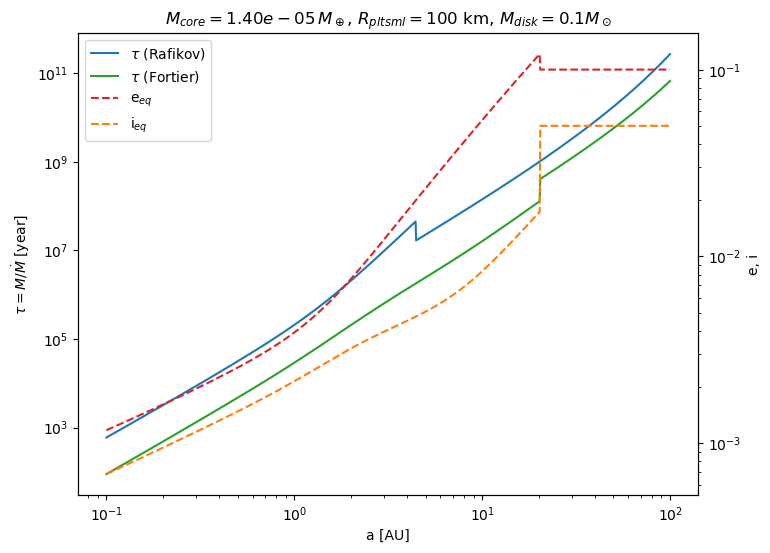

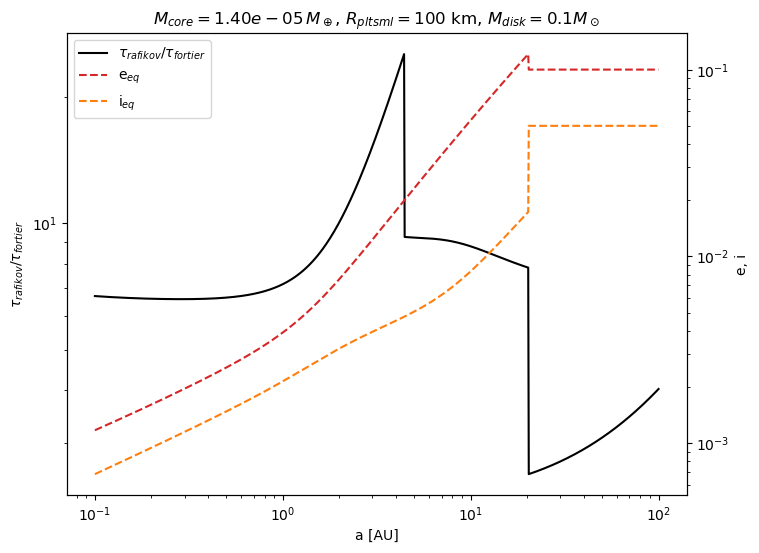

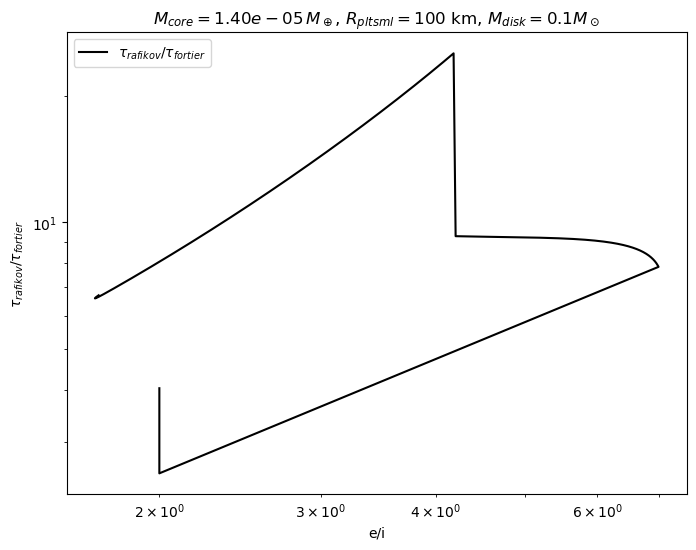

In [5]:
## tau vs a

drag = True
VS_embryo = True
VS_pltsml = True
DF = True

a_cores = np.logspace(-1, 2, 1000)
M = M_pltsml(R_pltsml) * 10 # Earth masses
R_pltsml = 100 # km
M_disk = 0.1 # Solar masses

tau_rafikov = []
tau_fortier = []
ratio  = []
e_eq = []
i_eq = []

for a in a_cores:

    sol = root(equilibrium, x0 = np.array([0.1 ** 2, (0.1 / 2) ** 2]), args = (a, [a], [M], drag, VS_embryo, VS_pltsml, DF), tol = 1e-12)

    e2_eq, i2_eq = sol.x

    Mdot_rafikov = dM_dt_rafikov(e2_eq, i2_eq, a, M)
    Mdot_fortier = dM_dt_fortier(e2_eq, i2_eq, a, M)

    tau_rafikov.append(M / Mdot_rafikov / year)
    tau_fortier.append(M / Mdot_fortier / year)
    ratio.append((M / Mdot_rafikov) / (M / Mdot_fortier))

    e_eq.append(np.sqrt(e2_eq))
    i_eq.append(np.sqrt(i2_eq))

## Plot growth timescales

fig, ax1 = plt.subplots(figsize = (8, 6))
ax2 = ax1.twinx()

ax1.plot(a_cores, tau_rafikov, color = 'tab:blue', label = r'$\tau$ (Rafikov)')
ax1.plot(a_cores, tau_fortier, color = 'tab:green', label = r'$\tau$ (Fortier)')
#ax1.axhline(1e6, color = 'black', linestyle = '--')
ax2.plot(a_cores, e_eq, color = 'tab:red', linestyle = '--', label = r'e$_{eq}$')
ax2.plot(a_cores, i_eq, color = 'tab:orange', linestyle = '--', label = r'i$_{eq}$')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.set_xlabel(r'a [AU]')
ax1.set_ylabel(r'$\tau = M / \dot M$ [year]')
ax2.set_ylabel(r'e, i')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = 'upper left')

plt.title(fr'$M_{{core}} = {M:.2e} \, M_\oplus$, $R_{{pltsml}} = {R_pltsml}$ km, $M_{{disk}} = {M_disk} M_\odot$')
plt.show()

## Plot timescale ratio

fig, ax1 = plt.subplots(figsize = (8, 6))
ax2 = ax1.twinx()

ax1.plot(a_cores, ratio, color = 'black', label = r'$\tau_{rafikov} / \tau_{fortier}$')
ax2.plot(a_cores, e_eq, color = 'tab:red', linestyle = '--', label = r'e$_{eq}$')
ax2.plot(a_cores, i_eq, color = 'tab:orange', linestyle = '--', label = r'i$_{eq}$')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.set_xlabel(r'a [AU]')
ax1.set_ylabel(r'$\tau_{rafikov} / \tau_{fortier}$')
ax2.set_ylabel(r'e, i')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = 'upper left')

plt.title(fr'$M_{{core}} = {M:.2e} \, M_\oplus$, $R_{{pltsml}} = {R_pltsml}$ km, $M_{{disk}} = {M_disk} M_\odot$')
plt.show()

## Plot timescale ratio vs e/i

fig, ax1 = plt.subplots(figsize = (8, 6))

ax1.plot(np.array(e_eq) / np.array(i_eq), ratio, color = 'black', label = r'$\tau_{rafikov} / \tau_{fortier}$')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(r'e/i')
ax1.set_ylabel(r'$\tau_{rafikov} / \tau_{fortier}$')

ax1.legend(loc = 'upper left')

plt.title(fr'$M_{{core}} = {M:.2e} \, M_\oplus$, $R_{{pltsml}} = {R_pltsml}$ km, $M_{{disk}} = {M_disk} M_\odot$')
plt.show()

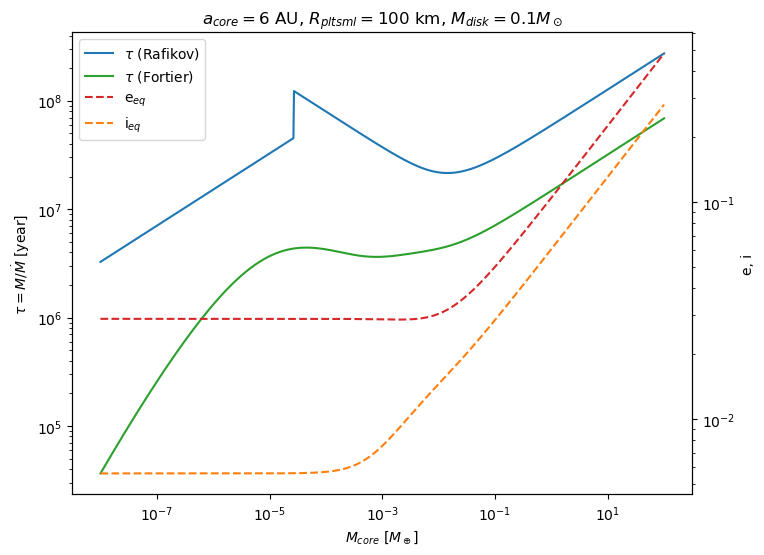

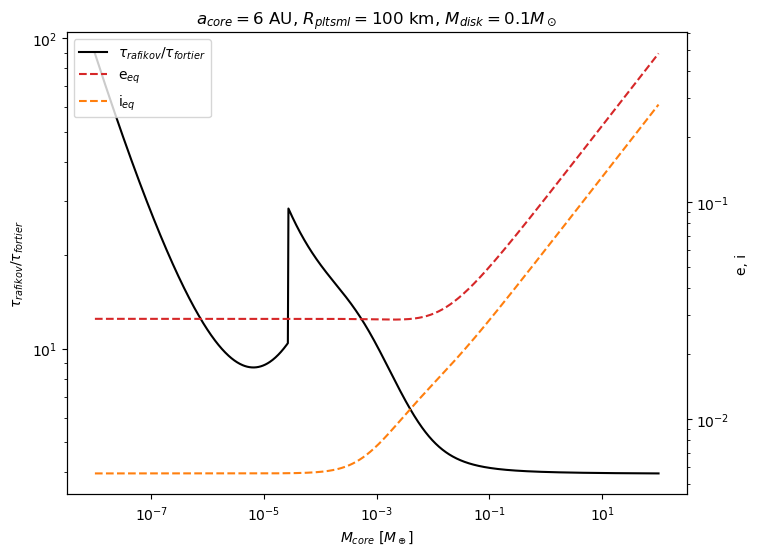

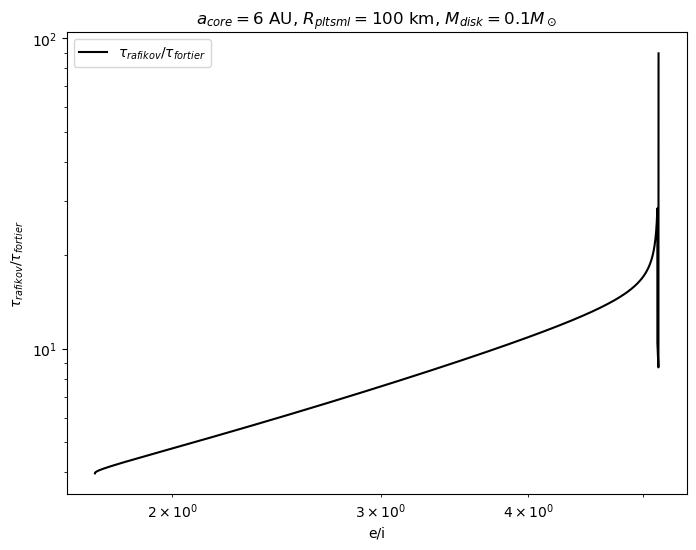

In [6]:
## tau vs M_core

drag = True
VS_embryo = True
VS_pltsml = True
DF = True

a = 6 # AU
M_cores = np.logspace(-8, 2, 1000) # Earth masses
R_pltsml = 100 # km
M_disk = 0.1 # Solar masses

tau_rafikov = []
tau_fortier = []
ratio = []
e_eq = []
i_eq = []

for M in M_cores:

    sol = root(equilibrium, x0 = np.array([0.1 ** 2, (0.1 / 2) ** 2]), args = (a, [a], [M], drag, VS_embryo, VS_pltsml, DF), tol = 1e-12)

    e2_eq, i2_eq = sol.x

    Mdot_rafikov = dM_dt_rafikov(e2_eq, i2_eq, a, M)
    Mdot_fortier = dM_dt_fortier(e2_eq, i2_eq, a, M)

    tau_rafikov.append(M / Mdot_rafikov / year)
    tau_fortier.append(M / Mdot_fortier / year)
    ratio.append((M / Mdot_rafikov) / (M / Mdot_fortier))
    
    e_eq.append(np.sqrt(e2_eq))
    i_eq.append(np.sqrt(i2_eq))

## Plot growth timescales

fig, ax1 = plt.subplots(figsize = (8, 6))
ax2 = ax1.twinx()

ax1.plot(M_cores, tau_rafikov, color = 'tab:blue', label = r'$\tau$ (Rafikov)')
ax1.plot(M_cores, tau_fortier, color = 'tab:green', label = r'$\tau$ (Fortier)')
#ax1.axhline(1e6, color = 'black', linestyle = '--')
ax2.plot(M_cores, e_eq, color = 'tab:red', linestyle = '--', label = r'e$_{eq}$')
ax2.plot(M_cores, i_eq, color = 'tab:orange', linestyle = '--', label = r'i$_{eq}$')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.set_xlabel(r'$M_{core}$ [$M_\oplus$]')
ax1.set_ylabel(r'$\tau = M / \dot M$ [year]')
ax2.set_ylabel(r'e, i')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = 'upper left')

plt.title(fr'$a_{{core}} = {a}$ AU, $R_{{pltsml}} = {R_pltsml}$ km, $M_{{disk}} = {M_disk} M_\odot$')
plt.show()

## Plot timescale ratio

fig, ax1 = plt.subplots(figsize = (8, 6))
ax2 = ax1.twinx()

ax1.plot(M_cores, ratio, color = 'black', label = r'$\tau_{rafikov} / \tau_{fortier}$')
ax2.plot(M_cores, e_eq, color = 'tab:red', linestyle = '--', label = r'e$_{eq}$')
ax2.plot(M_cores, i_eq, color = 'tab:orange', linestyle = '--', label = r'i$_{eq}$')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.set_xlabel(r'$M_{core}$ [$M_\oplus$]')
ax1.set_ylabel(r'$\tau_{rafikov} / \tau_{fortier}$')
ax2.set_ylabel(r'e, i')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = 'upper left')

plt.title(fr'$a_{{core}} = {a}$ AU, $R_{{pltsml}} = {R_pltsml}$ km, $M_{{disk}} = {M_disk} M_\odot$')
plt.show()

## Plot timescale ratio vs e/i

fig, ax1 = plt.subplots(figsize = (8, 6))

ax1.plot(np.array(e_eq) / np.array(i_eq), ratio, color = 'black', label = r'$\tau_{rafikov} / \tau_{fortier}$')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(r'e/i')
ax1.set_ylabel(r'$\tau_{rafikov} / \tau_{fortier}$')

ax1.legend(loc = 'upper left')

plt.title(fr'$a_{{core}} = {a}$ AU, $R_{{pltsml}} = {R_pltsml}$ km, $M_{{disk}} = {M_disk} M_\odot$')
plt.show()

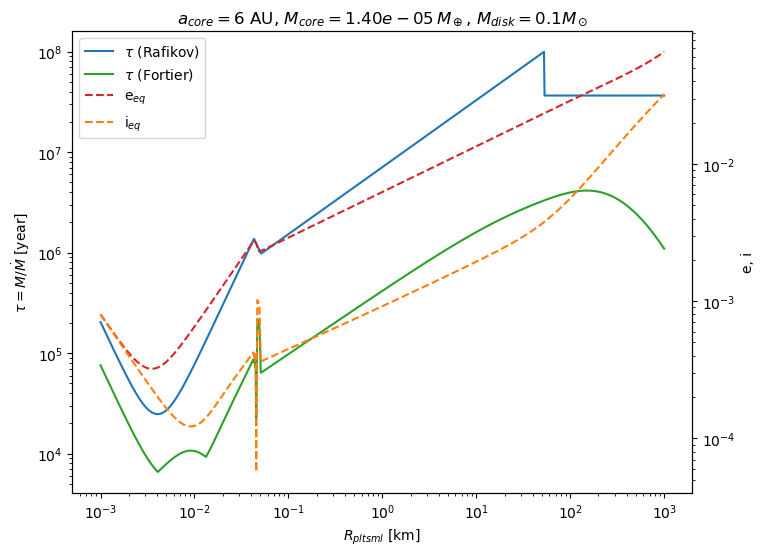

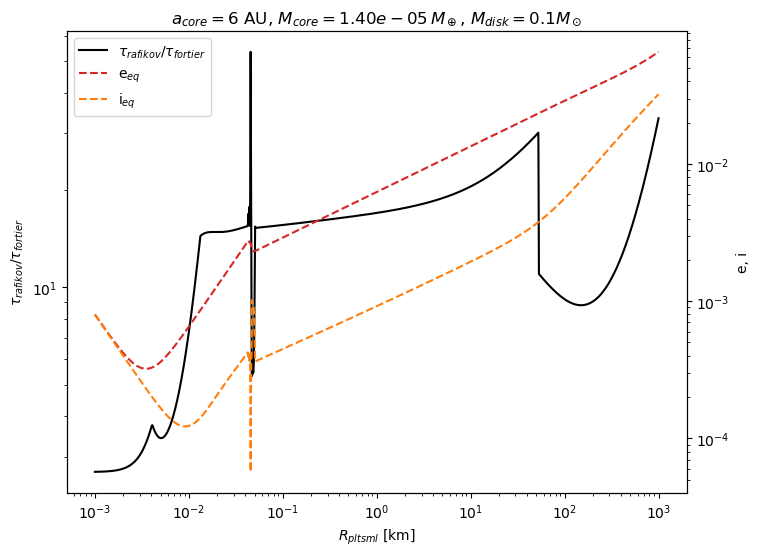

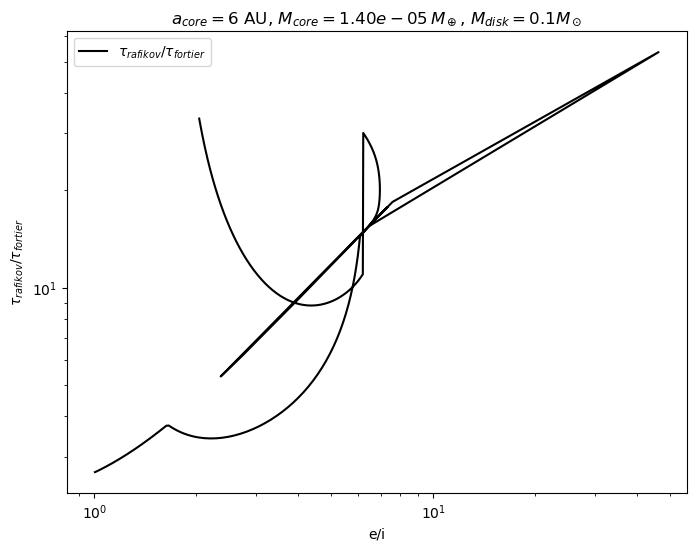

In [7]:
## tau vs R_pltsml

drag = True
VS_embryo = True
VS_pltsml = True
DF = True

a = 6 # AU
M = M_pltsml(R_pltsml) * 10 # Earth masses
R_pltsmls = np.logspace(-3, 3, 1000) # km
M_disk = 0.1 # Solar masses

tau_rafikov = []
tau_fortier = []
ratio = []
e_eq = []
i_eq = []

for R_pltsml in R_pltsmls:

    sol = root(equilibrium, x0 = np.array([0.1 ** 2, (0.1 / 2) ** 2]), args = (a, [a], [M], drag, VS_embryo, VS_pltsml, DF), tol = 1e-12)

    e2_eq, i2_eq = sol.x

    Mdot_rafikov = dM_dt_rafikov(e2_eq, i2_eq, a, M)
    Mdot_fortier = dM_dt_fortier(e2_eq, i2_eq, a, M)

    tau_rafikov.append(M / Mdot_rafikov / year)
    tau_fortier.append(M / Mdot_fortier / year)
    ratio.append((M / Mdot_rafikov) / (M / Mdot_fortier))
    
    e_eq.append(np.sqrt(e2_eq))
    i_eq.append(np.sqrt(i2_eq))

## Plot growth timescales

fig, ax1 = plt.subplots(figsize = (8, 6))
ax2 = ax1.twinx()

ax1.plot(R_pltsmls, tau_rafikov, color = 'tab:blue', label = r'$\tau$ (Rafikov)')
ax1.plot(R_pltsmls, tau_fortier, color = 'tab:green', label = r'$\tau$ (Fortier)')
#ax1.axhline(1e6, color = 'black', linestyle = '--')
ax2.plot(R_pltsmls, e_eq, color = 'tab:red', linestyle = '--', label = r'e$_{eq}$')
ax2.plot(R_pltsmls, i_eq, color = 'tab:orange', linestyle = '--', label = r'i$_{eq}$')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.set_xlabel(r'$R_{pltsml}$ [km]')
ax1.set_ylabel(r'$\tau = M / \dot M$ [year]')
ax2.set_ylabel(r'e, i')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = 'upper left')

plt.title(fr'$a_{{core}} = {a}$ AU, $M_{{core}} = {M:.2e} \, M_\oplus$, $M_{{disk}} = {M_disk} M_\odot$')
plt.show()

## Plot timescale ratio

fig, ax1 = plt.subplots(figsize = (8, 6))
ax2 = ax1.twinx()

ax1.plot(R_pltsmls, ratio, color = 'black', label = r'$\tau_{rafikov} / \tau_{fortier}$')
ax2.plot(R_pltsmls, e_eq, color = 'tab:red', linestyle = '--', label = r'e$_{eq}$')
ax2.plot(R_pltsmls, i_eq, color = 'tab:orange', linestyle = '--', label = r'i$_{eq}$')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.set_xlabel(r'$R_{pltsml}$ [km]')
ax1.set_ylabel(r'$\tau_{rafikov} / \tau_{fortier}$')
ax2.set_ylabel(r'e, i')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = 'upper left')

plt.title(fr'$a_{{core}} = {a}$ AU, $M_{{core}} = {M:.2e} \, M_\oplus$, $M_{{disk}} = {M_disk} M_\odot$')
plt.show()

## Plot timescale ratio vs e/i

fig, ax1 = plt.subplots(figsize = (8, 6))

ax1.plot(np.array(e_eq) / np.array(i_eq), ratio, color = 'black', label = r'$\tau_{rafikov} / \tau_{fortier}$')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(r'e/i')
ax1.set_ylabel(r'$\tau_{rafikov} / \tau_{fortier}$')

ax1.legend(loc = 'upper left')

plt.title(fr'$a_{{core}} = {a}$ AU, $M_{{core}} = {M:.2e} \, M_\oplus$, $M_{{disk}} = {M_disk} M_\odot$')
plt.show()

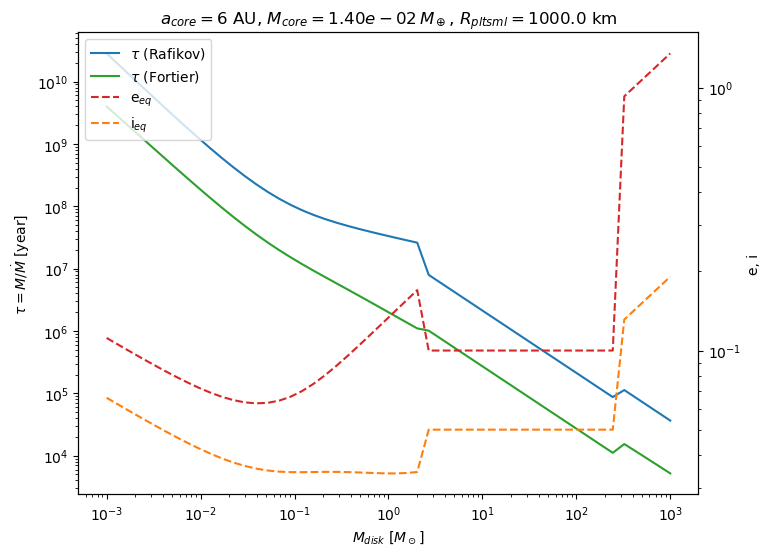

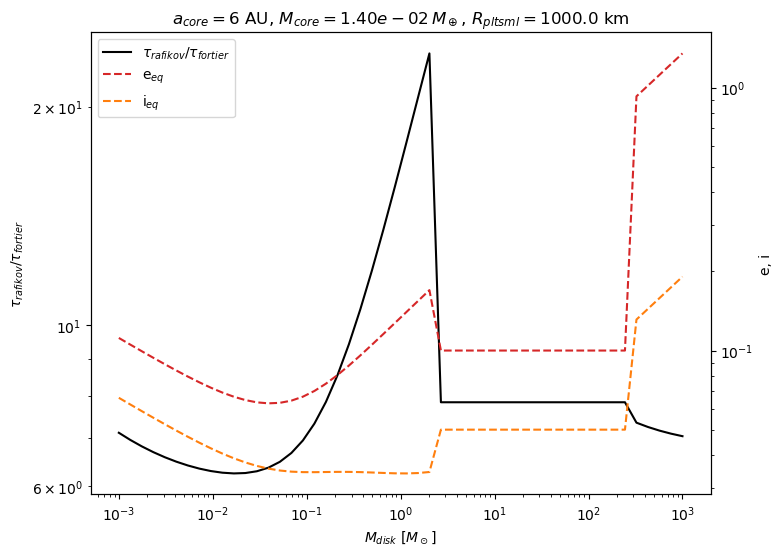

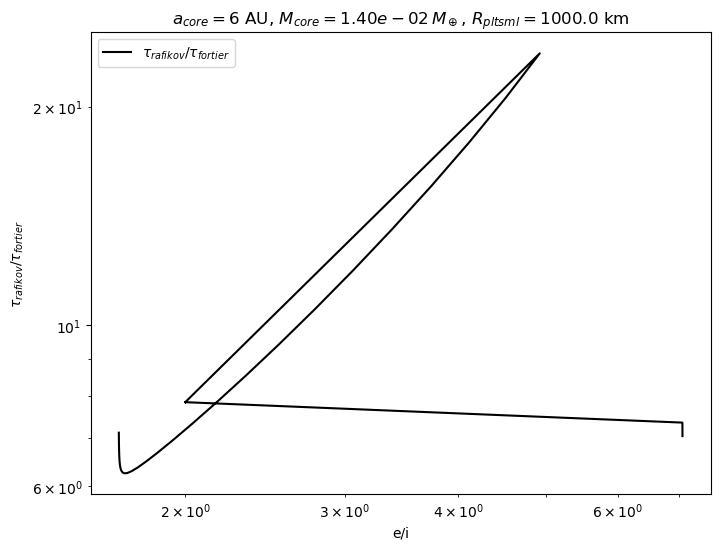

In [8]:
## tau vs R_pltsml

drag = True
VS_embryo = True
VS_pltsml = True
DF = True

a = 6 # AU
M = M_pltsml(R_pltsml) * 10 # Earth masses
R_pltsmls = 100 # km
M_disks = np.logspace(-3, 3) # Solar masses

tau_rafikov = []
tau_fortier = []
ratio = []
e_eq = []
i_eq = []

for M_disk in M_disks:

    sol = root(equilibrium, x0 = np.array([0.1 ** 2, (0.1 / 2) ** 2]), args = (a, [a], [M], drag, VS_embryo, VS_pltsml, DF), tol = 1e-12)

    e2_eq, i2_eq = sol.x

    Mdot_rafikov = dM_dt_rafikov(e2_eq, i2_eq, a, M)
    Mdot_fortier = dM_dt_fortier(e2_eq, i2_eq, a, M)

    tau_rafikov.append(M / Mdot_rafikov / year)
    tau_fortier.append(M / Mdot_fortier / year)
    ratio.append((M / Mdot_rafikov) / (M / Mdot_fortier))
    
    e_eq.append(np.sqrt(e2_eq))
    i_eq.append(np.sqrt(i2_eq))

## Plot growth timescales

fig, ax1 = plt.subplots(figsize = (8, 6))
ax2 = ax1.twinx()

ax1.plot(M_disks, tau_rafikov, color = 'tab:blue', label = r'$\tau$ (Rafikov)')
ax1.plot(M_disks, tau_fortier, color = 'tab:green', label = r'$\tau$ (Fortier)')
#ax1.axhline(1e6, color = 'black', linestyle = '--')
ax2.plot(M_disks, e_eq, color = 'tab:red', linestyle = '--', label = r'e$_{eq}$')
ax2.plot(M_disks, i_eq, color = 'tab:orange', linestyle = '--', label = r'i$_{eq}$')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.set_xlabel(r'$M_{disk}$ [$M_\odot$]')
ax1.set_ylabel(r'$\tau = M / \dot M$ [year]')
ax2.set_ylabel(r'e, i')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = 'upper left')

plt.title(fr'$a_{{core}} = {a}$ AU, $M_{{core}} = {M:.2e} \, M_\oplus$, $R_{{pltsml}} = {R_pltsml}$ km')
plt.show()

## Plot timescale ratio

fig, ax1 = plt.subplots(figsize = (8, 6))
ax2 = ax1.twinx()

ax1.plot(M_disks, ratio, color = 'black', label = r'$\tau_{rafikov} / \tau_{fortier}$')
ax2.plot(M_disks, e_eq, color = 'tab:red', linestyle = '--', label = r'e$_{eq}$')
ax2.plot(M_disks, i_eq, color = 'tab:orange', linestyle = '--', label = r'i$_{eq}$')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.set_xlabel(r'$M_{disk}$ [$M_\odot$]')
ax1.set_ylabel(r'$\tau_{rafikov} / \tau_{fortier}$')
ax2.set_ylabel(r'e, i')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = 'upper left')

plt.title(fr'$a_{{core}} = {a}$ AU, $M_{{core}} = {M:.2e} \, M_\oplus$, $R_{{pltsml}} = {R_pltsml}$ km')
plt.show()

## Plot timescale ratio vs e/i

fig, ax1 = plt.subplots(figsize = (8, 6))

ax1.plot(np.array(e_eq) / np.array(i_eq), ratio, color = 'black', label = r'$\tau_{rafikov} / \tau_{fortier}$')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(r'e/i')
ax1.set_ylabel(r'$\tau_{rafikov} / \tau_{fortier}$')

ax1.legend(loc = 'upper left')

plt.title(fr'$a_{{core}} = {a}$ AU, $M_{{core}} = {M:.2e} \, M_\oplus$, $R_{{pltsml}} = {R_pltsml}$ km')
plt.show()